# Sistema de Ruteo Seguro para CDMX

## Parte 2: Analisis Espacial y Modelado Predictivo

Este notebook tiene dos grandes etapas. En la primera se identifican patrones geograficos
de accidentalidad usando DBSCAN y analisis de hot spots (Getis-Ord Gi*). En la segunda
se construye un Stacking Ensemble para predecir la gravedad de los accidentes,
con manejo del desbalance de clases mediante SMOTE, busqueda de hiperparametros con
RandomizedSearchCV y optimizacion del umbral de decision.

Requiere que `01_preparacion_datos.ipynb` haya sido ejecutado primero.

Archivos que produce:
- `Datos combinados CDMX/ACCIDENTES_CON_CLUSTERING.csv`
- `Datos combinados CDMX/GRID_HOTSPOTS.csv`
- `Datos combinados CDMX/SCORING_RIESGO_COMPUESTO.csv`
- `modelos/modelo_riesgo_stack.pkl`, `modelos/scaler.pkl`, `modelos/feature_names.pkl`


## 1. Importaciones


In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from shapely.geometry import Point, box
from scipy import stats

from sklearn.cluster import DBSCAN
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, f1_score, roc_auc_score, precision_recall_curve
)

try:
    from esda.moran import Moran
    from esda.getisord import G_Local
    from libpysal.weights import DistanceBand
    from libpysal.weights.spatial_lag import lag_spatial
    PYSAL_OK = True
except ImportError:
    PYSAL_OK = False
    print('pysal / esda no disponibles. Las secciones de Moran y Getis-Ord se omitiran.')

try:
    from imblearn.over_sampling import SMOTE
    SMOTE_OK = True
except ImportError:
    SMOTE_OK = False
    print('imbalanced-learn no encontrado. Instalar con: pip install imbalanced-learn')
    print('El modelo se entrenara con class_weight="balanced" como alternativa.')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
%matplotlib inline

os.makedirs('Datos combinados CDMX', exist_ok=True)
os.makedirs('modelos', exist_ok=True)
os.makedirs('mapas', exist_ok=True)

print('Librerias cargadas.')
print(f'  SMOTE disponible:  {SMOTE_OK}')
print(f'  PySAL disponible:  {PYSAL_OK}')


Librerias cargadas.
  SMOTE disponible:  True
  PySAL disponible:  True


## 2. Carga de datos


In [30]:
df = pd.read_csv('Datos combinados CDMX/ACCIDENTES_CON_TRAMOS_2019_2023.csv')

print(f'Accidentes cargados: {len(df):,}')
print(f'Columnas: {len(df.columns)}')
df.head(3)


Accidentes cargados: 32,139
Columnas: 61


,id,edo,mes,anio,mpio,hora,minutos,dia,diasemana,urbana,...,hay_muertos,hay_heridos,solo_daños_materiales,severidad_cat,franja_horaria,geometry,edge_u,edge_v,edge_key,distancia_edge
0,408,9,1,2019,2,19,59,1,2,1,...,False,True,False,moderada,Noche,POINT (-99.20335 19.48374),269343999,372453602,0,0.270123
1,409,9,1,2019,2,3,37,5,6,1,...,False,False,True,leve,Madrugada,POINT (-99.20493 19.5135),8167712493,1932429931,0,0.213782
2,410,9,1,2019,2,14,23,5,6,1,...,False,False,True,leve,Tarde,POINT (-99.17616 19.46819),7982345896,7982345894,0,4.345150


## 3. Clustering espacial con DBSCAN

DBSCAN agrupa accidentes por proximidad geografica sin requerir que se especifique
el numero de clusters de antemano. Se usa la proyeccion UTM (EPSG:32614) para que
las distancias sean en metros reales. Con eps=200 y min_samples=20 se exige que
un cluster tenga al menos 20 accidentes dentro de 200 metros.


In [31]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['longitud'], df['latitud']),
    crs='EPSG:4326'
)
gdf_utm = gdf.to_crs('EPSG:32614')
coords_utm = np.array([[p.x, p.y] for p in gdf_utm.geometry])

dbscan = DBSCAN(eps=200, min_samples=20, metric='euclidean')
gdf['cluster_dbscan'] = dbscan.fit_predict(coords_utm)

n_clusters = gdf['cluster_dbscan'].nunique() - (1 if -1 in gdf['cluster_dbscan'].values else 0)
n_ruido = (gdf['cluster_dbscan'] == -1).sum()

print(f'Clusters encontrados:          {n_clusters}')
print(f'Puntos en clusters:  {len(gdf) - n_ruido:,} ({(len(gdf) - n_ruido) / len(gdf) * 100:.1f}%)')
print(f'Ruido (aislados):    {n_ruido:,} ({n_ruido / len(gdf) * 100:.1f}%)')


Clusters encontrados:          299
Puntos en clusters:  17,178 (53.4%)
Ruido (aislados):    14,961 (46.6%)


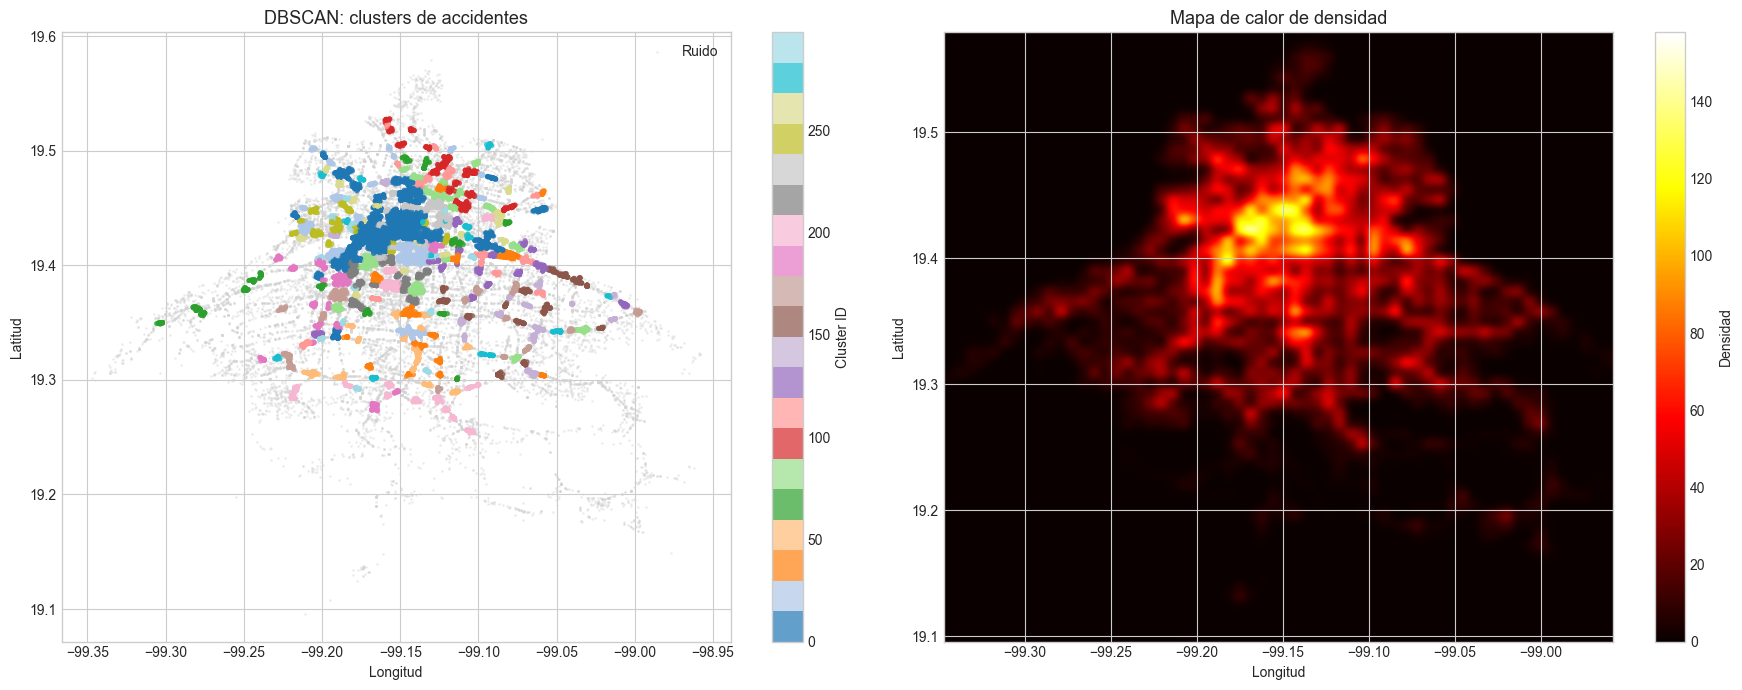

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ruido = gdf[gdf['cluster_dbscan'] == -1]
en_cluster = gdf[gdf['cluster_dbscan'] != -1]

axes[0].scatter(ruido['longitud'], ruido['latitud'],
                c='lightgray', s=1, alpha=0.3, label='Ruido')
sc = axes[0].scatter(en_cluster['longitud'], en_cluster['latitud'],
                     c=en_cluster['cluster_dbscan'], cmap='tab20', s=8, alpha=0.7)
plt.colorbar(sc, ax=axes[0], label='Cluster ID')
axes[0].set_title('DBSCAN: clusters de accidentes', fontsize=13)
axes[0].set_xlabel('Longitud')
axes[0].set_ylabel('Latitud')
axes[0].legend()

hm, xe, ye = np.histogram2d(gdf['longitud'], gdf['latitud'], bins=60)
im = axes[1].imshow(hm.T, origin='lower', extent=[xe[0], xe[-1], ye[0], ye[-1]],
                    cmap='hot', aspect='auto', interpolation='gaussian')
plt.colorbar(im, ax=axes[1], label='Densidad')
axes[1].set_title('Mapa de calor de densidad', fontsize=13)
axes[1].set_xlabel('Longitud')
axes[1].set_ylabel('Latitud')

plt.tight_layout()
plt.show()


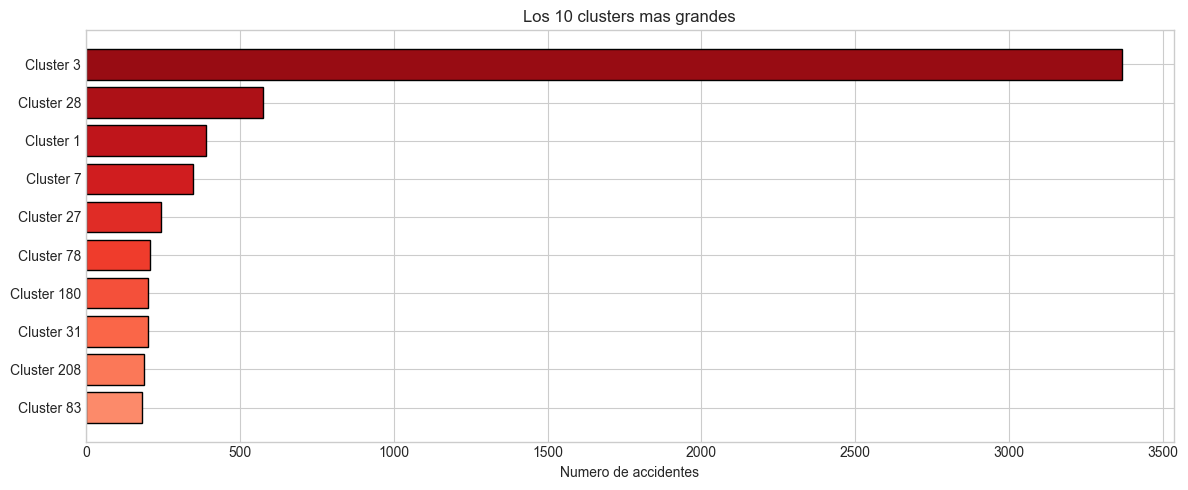

Tamano promedio de cluster: 57.5
Cluster mas grande:         3366 accidentes
Cluster mas pequeno:        3 accidentes


In [33]:
cluster_sizes = gdf[gdf['cluster_dbscan'] != -1].groupby('cluster_dbscan').size()

fig, ax = plt.subplots(figsize=(12, 5))
top_clusters = cluster_sizes.nlargest(10).sort_values(ascending=True)
colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(top_clusters)))
ax.barh(range(len(top_clusters)), top_clusters.values, color=colors, edgecolor='black')
ax.set_yticks(range(len(top_clusters)))
ax.set_yticklabels([f'Cluster {idx}' for idx in top_clusters.index])
ax.set_xlabel('Numero de accidentes')
ax.set_title('Los 10 clusters mas grandes')
plt.tight_layout()
plt.show()

print(f'Tamano promedio de cluster: {cluster_sizes.mean():.1f}')
print(f'Cluster mas grande:         {cluster_sizes.max()} accidentes')
print(f'Cluster mas pequeno:        {cluster_sizes.min()} accidentes')


## 4. Hot spots con Getis-Ord Gi*

Se divide CDMX en celdas de aproximadamente 1.1 km x 1.1 km y se cuenta el numero
de accidentes en cada una. Getis-Ord Gi* calcula un z-score para cada celda que
indica si su concentracion de accidentes es estadisticamente significativa comparada
con el entorno. Un z-score mayor a 2.58 indica hot spot con 99% de confianza.


In [34]:
CELL_SIZE = 0.01
minx, miny, maxx, maxy = gdf.total_bounds

grid_cells = []
for i in range(int(np.ceil((maxx - minx) / CELL_SIZE))):
    for j in range(int(np.ceil((maxy - miny) / CELL_SIZE))):
        c = box(minx + i*CELL_SIZE, miny + j*CELL_SIZE,
                minx + (i+1)*CELL_SIZE, miny + (j+1)*CELL_SIZE)
        grid_cells.append(c)

grid = gpd.GeoDataFrame({'geometry': grid_cells}, crs=gdf.crs)
grid['n_accidentes'] = grid.geometry.apply(lambda c: gdf[gdf.within(c)].shape[0])
grid = grid[grid['n_accidentes'] > 0].reset_index(drop=True)

print(f'Celdas con accidentes: {len(grid):,}')
print(f'Promedio por celda:    {grid["n_accidentes"].mean():.1f}')
print(f'Maximo en una celda:   {grid["n_accidentes"].max()}')


Celdas con accidentes: 755
Promedio por celda:    42.6
Maximo en una celda:   277


In [35]:
if PYSAL_OK:
    coords = np.array([[g.centroid.x, g.centroid.y] for g in grid.geometry])
    w = DistanceBand(coords, threshold=0.02, binary=True)
    vals = grid['n_accidentes'].values.astype(np.float64)

    g_local = G_Local(vals, w, star=True, permutations=0)
    grid['gi_score'] = g_local.Zs

    grid['hot_spot'] = 'No significativo'
    grid.loc[grid['gi_score'] > 2.58,  'hot_spot'] = 'Hot Spot (99%)'
    grid.loc[(grid['gi_score'] > 1.96) & (grid['gi_score'] <= 2.58), 'hot_spot'] = 'Hot Spot (95%)'
    grid.loc[grid['gi_score'] < -2.58, 'hot_spot'] = 'Cold Spot (99%)'
    grid.loc[(grid['gi_score'] < -1.96) & (grid['gi_score'] >= -2.58), 'hot_spot'] = 'Cold Spot (95%)'

    print('Getis-Ord Gi* calculado.')
    print(grid['hot_spot'].value_counts().to_string())
else:
    grid['gi_score'] = np.nan
    grid['hot_spot'] = 'No calculado'
    print('PySAL no disponible. Se omite el analisis de hot spots.')


('WARNING: ', 50, ' is an island (no neighbors)')
('WARNING: ', 746, ' is an island (no neighbors)')
Getis-Ord Gi* calculado.
hot_spot
No significativo    725
Hot Spot (95%)       17
Hot Spot (99%)       13


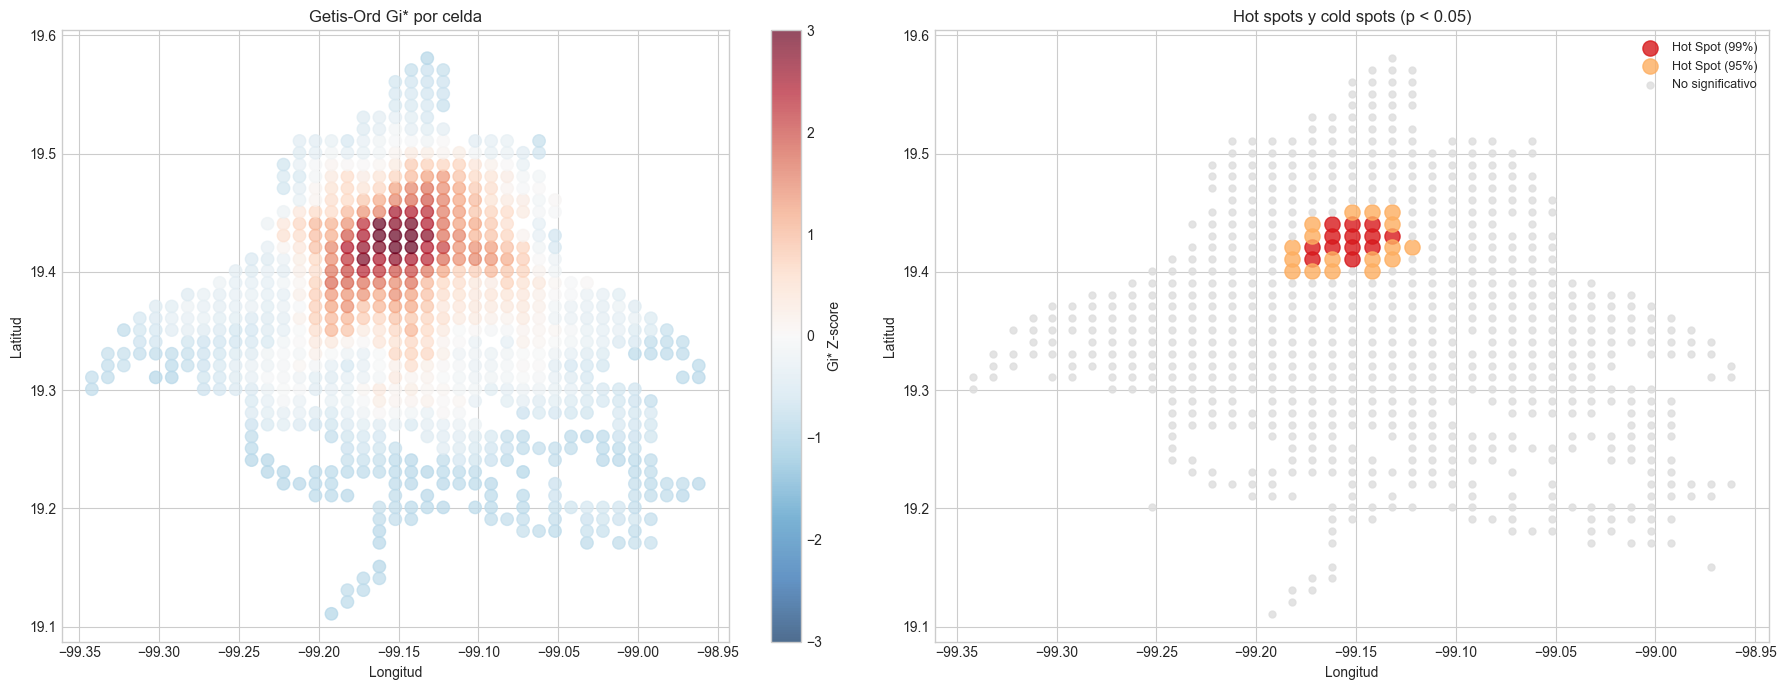

In [36]:
if PYSAL_OK and grid['gi_score'].notna().any():
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    sc = axes[0].scatter(grid.geometry.centroid.x, grid.geometry.centroid.y,
                         c=grid['gi_score'], cmap='RdBu_r', s=80, alpha=0.7, vmin=-3, vmax=3)
    plt.colorbar(sc, ax=axes[0], label='Gi* Z-score')
    axes[0].set_title('Getis-Ord Gi* por celda')
    axes[0].set_xlabel('Longitud'); axes[0].set_ylabel('Latitud')

    paleta = {
        'Hot Spot (99%)':  '#d7191c',
        'Hot Spot (95%)':  '#fdae61',
        'No significativo':'#dddddd',
        'Cold Spot (95%)': '#abd9e9',
        'Cold Spot (99%)': '#2b83ba',
    }
    for label, color in paleta.items():
        subset = grid[grid['hot_spot'] == label]
        if len(subset) > 0:
            sz = 120 if 'Spot' in label else 25
            axes[1].scatter(subset.geometry.centroid.x, subset.geometry.centroid.y,
                            c=color, label=label, s=sz, alpha=0.8)
    axes[1].set_title('Hot spots y cold spots (p < 0.05)')
    axes[1].set_xlabel('Longitud'); axes[1].set_ylabel('Latitud')
    axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.show()


## 5. Autocorrelacion espacial global (Moran's I)

Moran's I mide si los accidentes tienden a concentrarse cerca de otros accidentes.
Un valor positivo cercano a 1 con p < 0.05 confirma que el patron no es aleatorio
y que existe clustering espacial estadisticamente significativo.


('WARNING: ', 50, ' is an island (no neighbors)')
('WARNING: ', 746, ' is an island (no neighbors)')
Moran's I global:  0.6837
Valor esperado:    -0.0013
p-value:           0.0010
Clustering espacial positivo y estadisticamente significativo.


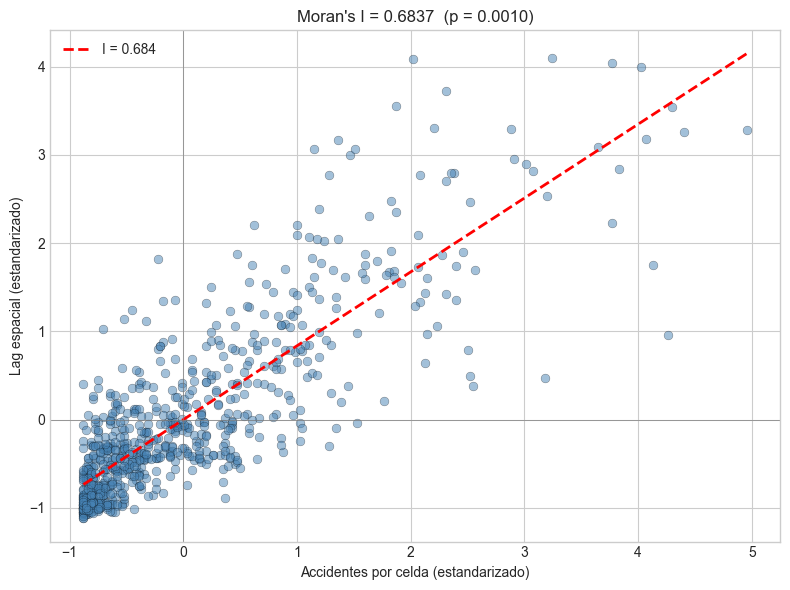

In [37]:
if PYSAL_OK:
    try:
        moran = Moran(grid['n_accidentes'].values, w)
        print(f"Moran's I global:  {moran.I:.4f}")
        print(f"Valor esperado:    {moran.EI:.4f}")
        print(f"p-value:           {moran.p_sim:.4f}")

        if moran.p_sim < 0.05 and moran.I > 0:
            print("Clustering espacial positivo y estadisticamente significativo.")

        # Scatter plot de Moran
        values = grid['n_accidentes'].values.astype(float)
        lag = lag_spatial(w, values)
        x = (values - values.mean()) / values.std()
        y = (lag - lag.mean()) / lag.std()

        fig, ax = plt.subplots(figsize=(8, 6))
        ax.scatter(x, y, alpha=0.5, s=40, c='steelblue', edgecolors='black', linewidth=0.3)
        slope = np.polyfit(x, y, 1)
        line_x = np.array([x.min(), x.max()])
        ax.plot(line_x, np.polyval(slope, line_x), 'r--', linewidth=2,
                label=f"I = {moran.I:.3f}")
        ax.axhline(0, color='gray', linewidth=0.5)
        ax.axvline(0, color='gray', linewidth=0.5)
        ax.set_xlabel('Accidentes por celda (estandarizado)')
        ax.set_ylabel('Lag espacial (estandarizado)')
        ax.set_title(f"Moran's I = {moran.I:.4f}  (p = {moran.p_sim:.4f})")
        ax.legend()
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f'Error: {e}')
else:
    print('PySAL no disponible.')


## 6. Indice de riesgo por clustering y exportacion


In [38]:
# Riesgo por cluster: 0 si es ruido, entre 50 y 100 segun el tamano del cluster
gdf['riesgo_cluster'] = 0.0
gdf.loc[gdf['cluster_dbscan'] != -1, 'riesgo_cluster'] = 50.0

sizes = gdf[gdf['cluster_dbscan'] != -1].groupby('cluster_dbscan').size()
min_s, max_s = sizes.min(), sizes.max()
for cid, sz in sizes.items():
    riesgo = 50 + (sz - min_s) / max(max_s - min_s, 1) * 50
    gdf.loc[gdf['cluster_dbscan'] == cid, 'riesgo_cluster'] = riesgo

# Riesgo por hotspot: 50 base, hasta 100 para los hot spots mas intensos
grid['riesgo_hotspot'] = 50.0
if 'gi_score' in grid.columns and grid['gi_score'].notna().any():
    max_gi = grid['gi_score'].max()
    if max_gi > 0:
        mask = grid['gi_score'] > 0
        grid.loc[mask, 'riesgo_hotspot'] = 50 + (grid.loc[mask, 'gi_score'] / max_gi) * 50

# Exportar
gdf[['id', 'latitud', 'longitud', 'cluster_dbscan', 'riesgo_cluster']].to_csv(
    'Datos combinados CDMX/ACCIDENTES_CON_CLUSTERING.csv', index=False)

grid['centroid_lat'] = grid.geometry.centroid.y
grid['centroid_lon'] = grid.geometry.centroid.x
grid[['centroid_lat', 'centroid_lon', 'n_accidentes',
      'gi_score', 'hot_spot', 'riesgo_hotspot']].to_csv(
    'Datos combinados CDMX/GRID_HOTSPOTS.csv', index=False)

print('Archivos exportados:')
print('  Datos combinados CDMX/ACCIDENTES_CON_CLUSTERING.csv')
print('  Datos combinados CDMX/GRID_HOTSPOTS.csv')


Archivos exportados:
  Datos combinados CDMX/ACCIDENTES_CON_CLUSTERING.csv
  Datos combinados CDMX/GRID_HOTSPOTS.csv


## 7. Modelado predictivo de gravedad

El objetivo es predecir si un accidente sera grave o no. La clase grave representa
alrededor del 3% de los datos, lo que hace que accuracy sea una metrica enganosa.
Se usa SMOTE (si esta disponible) para generar muestras sinteticas de la clase
minoritaria solo en el conjunto de entrenamiento, y se evaluan los modelos con
ROC-AUC y F1 de la clase grave.


In [39]:
df_ml = pd.read_csv('Datos combinados CDMX/ACCIDENTES_CON_TRAMOS_2019_2023.csv')

try:
    df_clust = pd.read_csv('Datos combinados CDMX/ACCIDENTES_CON_CLUSTERING.csv')
    df_ml = df_ml.merge(df_clust[['id', 'cluster_dbscan', 'riesgo_cluster']],
                        on='id', how='left')
    df_ml['en_cluster'] = (df_ml['cluster_dbscan'] != -1).astype(int)
    df_ml['riesgo_cluster'] = df_ml['riesgo_cluster'].fillna(0)
except FileNotFoundError:
    df_ml['en_cluster'] = 0
    df_ml['riesgo_cluster'] = 0

print(f'Dataset: {len(df_ml):,} registros')


Dataset: 42,851 registros


Distribucion de la variable objetivo:
  No grave (0): 41,620  (97.1%)
  Grave    (1): 1,231  (2.9%)


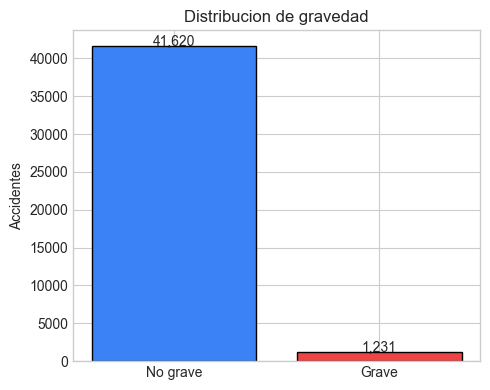

In [40]:
df_ml['es_grave'] = df_ml['severidad_cat'].isin(['grave', 'muy grave']).astype(int)

dist = df_ml['es_grave'].value_counts()
print('Distribucion de la variable objetivo:')
print(f'  No grave (0): {dist.get(0, 0):,}  ({dist.get(0, 0)/len(df_ml)*100:.1f}%)')
print(f'  Grave    (1): {dist.get(1, 0):,}  ({dist.get(1, 0)/len(df_ml)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['No grave', 'Grave'], [dist.get(0,0), dist.get(1,0)],
       color=['#3b82f6', '#ef4444'], edgecolor='black')
ax.set_ylabel('Accidentes')
ax.set_title('Distribucion de gravedad')
for i, v in enumerate([dist.get(0,0), dist.get(1,0)]):
    ax.text(i, v + 50, f'{v:,}', ha='center')
plt.tight_layout()
plt.show()


### Seleccion de variables por votacion

Se aplican tres metodos de seleccion de forma independiente. Solo se conservan
las variables que aparecen en al menos dos de los tres metodos.


Variables seleccionadas (16): ['clase', 'aliento', 'automovil', 'longitud', 'camioneta', 'cinturon', 'hora', 'sexo', 'caparod', 'distancia_edge', 'latitud', 'tipaccid', 'campasaj', 'motociclet', 'en_cluster', 'riesgo_cluster']


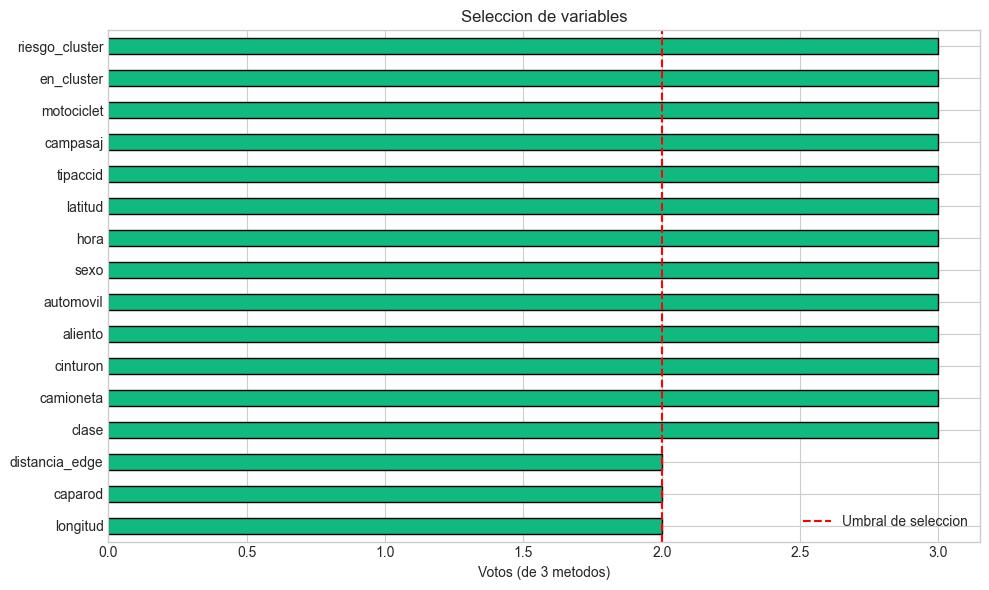

In [41]:
CANDIDATOS = ['clase', 'aliento', 'automovil', 'longitud', 'camioneta',
              'cinturon', 'hora', 'sexo', 'caparod', 'distancia_edge',
              'latitud', 'tipaccid', 'campasaj', 'motociclet',
              'en_cluster', 'riesgo_cluster']

features_ok = [c for c in CANDIDATOS if c in df_ml.columns]
df_clean = df_ml[features_ok + ['es_grave']].dropna()
X_all = df_clean[features_ok]
y_all = df_clean['es_grave']

votos = {f: 0 for f in features_ok}
TOP_K = min(15, len(features_ok))

skb = SelectKBest(f_classif, k=TOP_K)
skb.fit(X_all, y_all)
for f in np.array(features_ok)[skb.get_support()]:
    votos[f] += 1

rf_sel = RandomForestClassifier(n_estimators=100, max_depth=8,
                                class_weight='balanced', random_state=42, n_jobs=-1)
rf_sel.fit(X_all, y_all)
imp = pd.Series(rf_sel.feature_importances_, index=features_ok)
for f in imp.nlargest(TOP_K).index:
    votos[f] += 1

lr_rfe = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)
rfe = RFE(lr_rfe, n_features_to_select=TOP_K)
rfe.fit(X_all, y_all)
for f in np.array(features_ok)[rfe.get_support()]:
    votos[f] += 1

FEATURES = [f for f, v in votos.items() if v >= 2]
print(f'Variables seleccionadas ({len(FEATURES)}): {FEATURES}')

votes_df = pd.Series(votos).sort_values(ascending=True)
colors = ['#10b981' if v >= 2 else '#9ca3af' for v in votes_df.values]
fig, ax = plt.subplots(figsize=(10, 6))
votes_df.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.axvline(2, color='red', linestyle='--', linewidth=1.5, label='Umbral de seleccion')
ax.set_xlabel('Votos (de 3 metodos)')
ax.set_title('Seleccion de variables')
ax.legend()
plt.tight_layout()
plt.show()


### Division train/test y aplicacion de SMOTE

SMOTE crea muestras sinteticas de la clase minoritaria (grave) interpolando
entre puntos existentes. Se aplica unicamente sobre el conjunto de entrenamiento
para que la evaluacion en el conjunto de prueba refleje el problema real.


In [42]:
X = df_clean[FEATURES].copy()
y = df_clean['es_grave'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

if SMOTE_OK:
    smote = SMOTE(random_state=42, k_neighbors=5)
    X_train_res, y_train_res = smote.fit_resample(X_train_sc, y_train)
    nueva_dist = pd.Series(y_train_res).value_counts()
    print('Distribucion despues de SMOTE:')
    print(f'  No grave: {nueva_dist.get(0, 0):,}')
    print(f'  Grave:    {nueva_dist.get(1, 0):,}')
else:
    X_train_res, y_train_res = X_train_sc, y_train
    print('Entrenando sin SMOTE (class_weight="balanced").')

cw = None if SMOTE_OK else 'balanced'
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'\nMuestras de entrenamiento: {len(X_train_res):,}')
print(f'Muestras de prueba:        {len(X_test):,}')


Distribucion despues de SMOTE:
  No grave: 33,295
  Grave:    33,295

Muestras de entrenamiento: 66,590
Muestras de prueba:        8,571


## 8. Entrenamiento y evaluacion de modelos


### Arbol de Decision


In [43]:
dt = DecisionTreeClassifier(max_depth=6, min_samples_split=80,
                             min_samples_leaf=40, class_weight=cw, random_state=42)
dt.fit(X_train_res, y_train_res)

cv_dt = cross_val_score(dt, X_train_res, y_train_res, cv=skf, scoring='roc_auc')
print(f'ROC-AUC en CV (5 folds): {cv_dt.mean():.3f} +/- {cv_dt.std():.3f}')
print(classification_report(y_test, dt.predict(X_test_sc), target_names=['No grave', 'Grave']))


ROC-AUC en CV (5 folds): 0.992 +/- 0.000
              precision    recall  f1-score   support

    No grave       1.00      0.94      0.97      8325
       Grave       0.32      0.90      0.47       246

    accuracy                           0.94      8571
   macro avg       0.66      0.92      0.72      8571
weighted avg       0.98      0.94      0.95      8571



### Regresion Logistica


In [44]:
lr = LogisticRegression(max_iter=1000, class_weight=cw, C=1.0, random_state=42)
lr.fit(X_train_res, y_train_res)

cv_lr = cross_val_score(lr, X_train_res, y_train_res, cv=skf, scoring='roc_auc')
print(f'ROC-AUC en CV (5 folds): {cv_lr.mean():.3f} +/- {cv_lr.std():.3f}')
print(classification_report(y_test, lr.predict(X_test_sc), target_names=['No grave', 'Grave']))


ROC-AUC en CV (5 folds): 0.985 +/- 0.001
              precision    recall  f1-score   support

    No grave       1.00      0.90      0.95      8325
       Grave       0.22      0.95      0.35       246

    accuracy                           0.90      8571
   macro avg       0.61      0.92      0.65      8571
weighted avg       0.98      0.90      0.93      8571



### Random Forest con busqueda de hiperparametros

Se evaluan 30 combinaciones aleatorias del espacio de hiperparametros usando
validacion cruzada estratificada con 5 folds. La metrica de seleccion es ROC-AUC.


In [45]:
param_dist = {
    'n_estimators':      [100, 200, 300, 400],
    'max_depth':         [6, 8, 10, 12, None],
    'min_samples_split': [20, 40, 60, 80],
    'min_samples_leaf':  [10, 20, 30, 40],
    'max_features':      ['sqrt', 'log2', 0.5],
}

search = RandomizedSearchCV(
    RandomForestClassifier(class_weight=cw, random_state=42, n_jobs=-1),
    param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=skf,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train_res, y_train_res)

print('Mejores hiperparametros:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')
print(f'ROC-AUC en CV: {search.best_score_:.4f}')

rf = search.best_estimator_
print(classification_report(y_test, rf.predict(X_test_sc), target_names=['No grave', 'Grave']))


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Mejores hiperparametros:
  n_estimators: 100
  min_samples_split: 40
  min_samples_leaf: 10
  max_features: log2
  max_depth: None
ROC-AUC en CV: 0.9993
              precision    recall  f1-score   support

    No grave       1.00      0.99      0.99      8325
       Grave       0.68      0.87      0.76       246

    accuracy                           0.98      8571
   macro avg       0.84      0.93      0.88      8571
weighted avg       0.99      0.98      0.99      8571



### Stacking Ensemble


In [71]:
estimators_list = [
    ('rf',  rf),
    ('et',  ExtraTreesClassifier(n_estimators=300, class_weight=cw,
                                 min_samples_leaf=4,
                                 random_state=42, n_jobs=-1)),
    ('hgb', HistGradientBoostingClassifier(max_iter=300, max_depth=4,
                                            learning_rate=0.05,
                                            class_weight='balanced',
                                            random_state=42)),
    ('lr',  LogisticRegression(max_iter=1000, class_weight=cw, C=1.0, random_state=42))]
stack = StackingClassifier(
    estimators=estimators_list,
    final_estimator=HistGradientBoostingClassifier(
        max_iter=200, max_depth=3, learning_rate=0.05,
        class_weight='balanced', random_state=42),
    cv=5, stack_method='predict_proba', passthrough=True, n_jobs=-1)
stack.fit(X_train_res, y_train_res)

cv_stack = cross_val_score(stack, X_train_res, y_train_res, cv=skf, scoring='roc_auc')
print(f'ROC-AUC en CV (5 folds): {cv_stack.mean():.3f} +/- {cv_stack.std():.3f}')
print(classification_report(y_test, stack.predict(X_test_sc), target_names=['No grave', 'Grave']))

ROC-AUC en CV (5 folds): 1.000 +/- 0.000
              precision    recall  f1-score   support

    No grave       0.99      0.99      0.99      8325
       Grave       0.82      0.83      0.82       246

    accuracy                           0.99      8571
   macro avg       0.91      0.91      0.91      8571
weighted avg       0.99      0.99      0.99      8571



Para este contexto (seguridad vial), un recall más alto puede ser preferible.

## 9. Comparacion de modelos

ROC-AUC y F1 de la clase grave son las metricas relevantes aqui. La accuracy
puede ser alta simplemente prediciendo siempre la clase mayoritaria, por eso
no se usa como criterio de seleccion.


In [72]:
modelos = {'Decision Tree': dt, 'Logistic Regression': lr,
           'Random Forest': rf, 'Stacking': stack}

resultados = []
for nombre, modelo in modelos.items():
    y_prob = modelo.predict_proba(X_test_sc)[:, 1]
    y_pred = modelo.predict(X_test_sc)
    resultados.append({
        'Modelo':     nombre,
        'ROC-AUC':    round(roc_auc_score(y_test, y_prob), 4),
        'F1 grave':   round(f1_score(y_test, y_pred, pos_label=1), 4),
        'F1 macro':   round(f1_score(y_test, y_pred, average='macro'), 4),
    })

df_res = pd.DataFrame(resultados).sort_values('ROC-AUC', ascending=False)
print(df_res.to_string(index=False))


             Modelo  ROC-AUC  F1 grave  F1 macro
      Random Forest   0.9904    0.7621    0.8770
           Stacking   0.9883    0.8235    0.9092
Logistic Regression   0.9869    0.3517    0.6487
      Decision Tree   0.9855    0.4667    0.7178


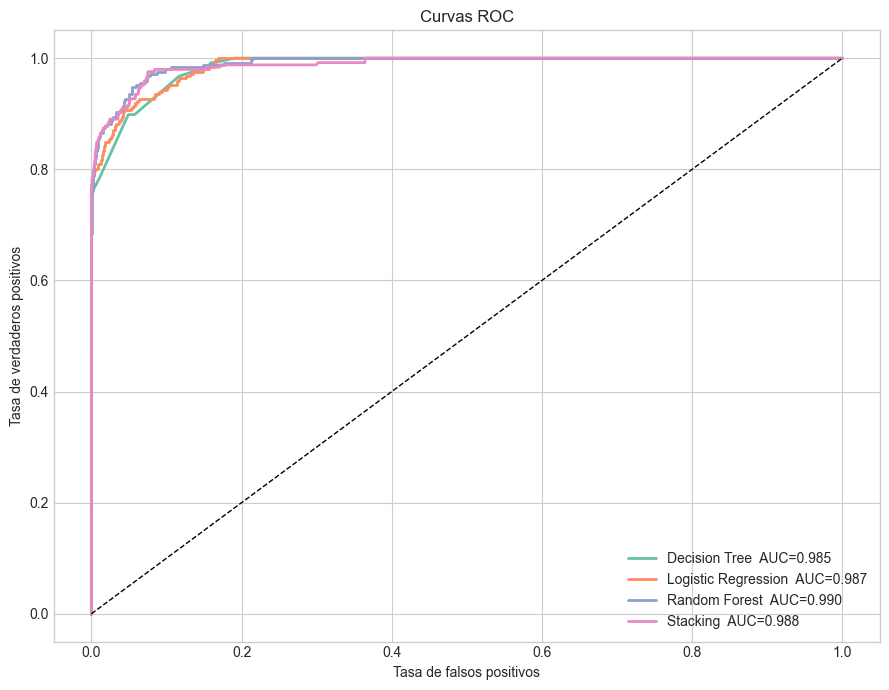

In [73]:
fig, ax = plt.subplots(figsize=(9, 7))
for nombre, modelo in modelos.items():
    y_prob = modelo.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, linewidth=2, label=f'{nombre}  AUC={auc_val:.3f}')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel('Tasa de falsos positivos')
ax.set_ylabel('Tasa de verdaderos positivos')
ax.set_title('Curvas ROC')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 10. Optimizacion del umbral de decision

El modelo produce una probabilidad P(grave) entre 0 y 1 para cada accidente.
Por defecto, se clasifica como grave si P(grave) >= 0.5, pero con clases
desbalanceadas ese corte no es optimo. Aqui se busca el umbral que
maximiza el F1 de la clase grave usando la curva precision-recall.


Umbral por defecto (0.5):
  F1 grave = 0.8235
Umbral optimo (0.941):
  F1 grave = 0.8656


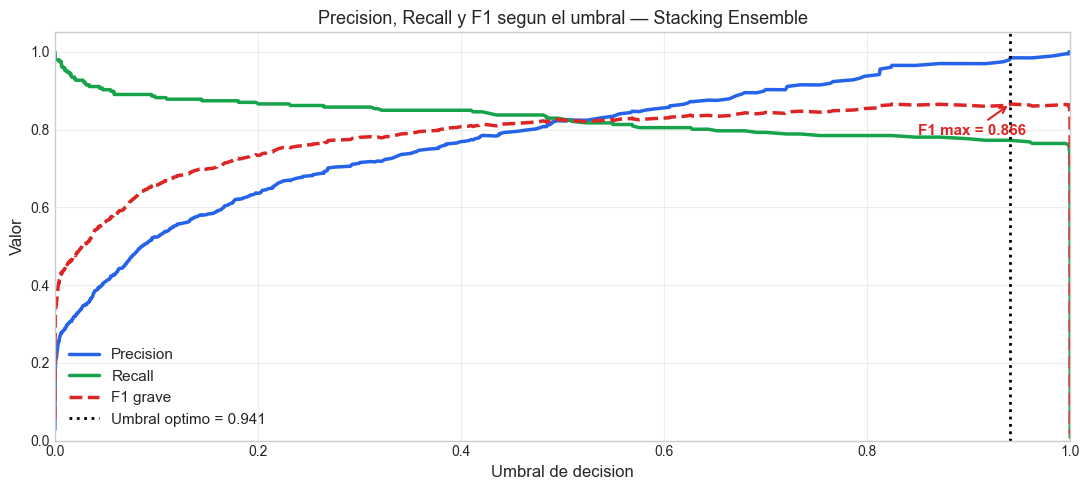

In [74]:
y_prob_stack = stack.predict_proba(X_test_sc)[:, 1]
precision_arr, recall_arr, thresholds = precision_recall_curve(y_test, y_prob_stack)

f1_arr = (2 * precision_arr[:-1] * recall_arr[:-1]
          / np.maximum(precision_arr[:-1] + recall_arr[:-1], 1e-9))
best_idx       = np.argmax(f1_arr)
best_threshold = thresholds[best_idx]

print(f'Umbral por defecto (0.5):')
print(f'  F1 grave = {f1_score(y_test, (y_prob_stack >= 0.5).astype(int)):.4f}')
print(f'Umbral optimo ({best_threshold:.3f}):')
print(f'  F1 grave = {f1_arr[best_idx]:.4f}')

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(thresholds, precision_arr[:-1], label='Precision', linewidth=2.5, color='#2563eb')
ax.plot(thresholds, recall_arr[:-1],    label='Recall',    linewidth=2.5, color='#16a34a')
ax.plot(thresholds, f1_arr,             label='F1 grave',  linewidth=2.5,
        linestyle='--', color='#dc2626')
ax.axvline(best_threshold, color='black', linestyle=':', linewidth=2,
           label=f'Umbral optimo = {best_threshold:.3f}')
ax.annotate(f'F1 max = {f1_arr[best_idx]:.3f}',
            xy=(best_threshold, f1_arr[best_idx]),
            xytext=(min(best_threshold + 0.07, 0.85), f1_arr[best_idx] - 0.08),
            fontsize=11, fontweight='bold', color='#dc2626',
            arrowprops=dict(arrowstyle='->', color='#dc2626', lw=1.5))
ax.set_xlabel('Umbral de decision', fontsize=12)
ax.set_ylabel('Valor', fontsize=12)
ax.set_title('Precision, Recall y F1 segun el umbral — Stacking Ensemble', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

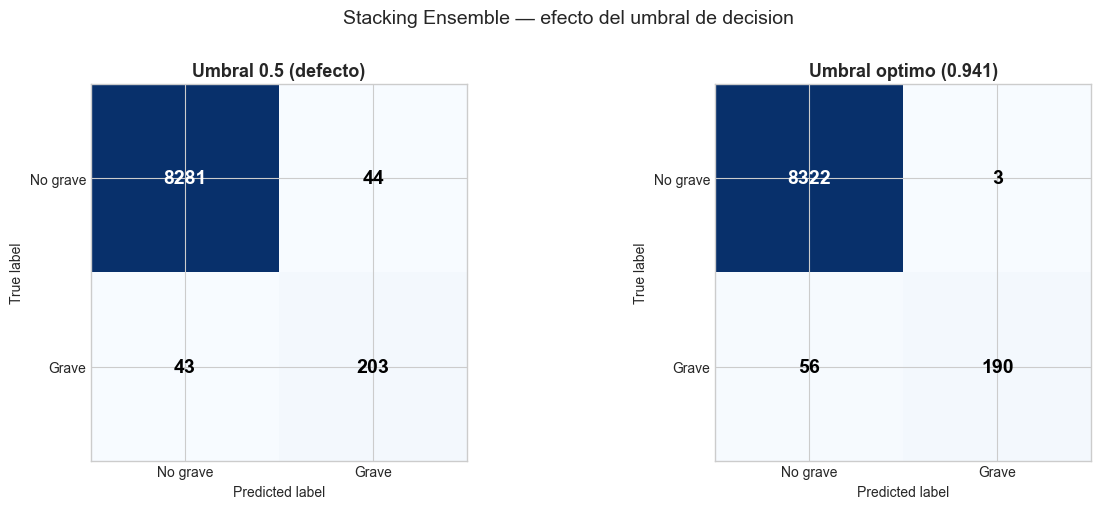

Reporte con umbral optimizado:
              precision    recall  f1-score   support

    No grave       0.99      1.00      1.00      8325
       Grave       0.98      0.77      0.87       246

    accuracy                           0.99      8571
   macro avg       0.99      0.89      0.93      8571
weighted avg       0.99      0.99      0.99      8571



In [75]:
y_pred_default = stack.predict(X_test_sc)
y_pred_opt     = (y_prob_stack >= best_threshold).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, preds, titulo in zip(
    axes,
    [y_pred_default, y_pred_opt],
    ['Umbral 0.5 (defecto)', f'Umbral optimo ({best_threshold:.3f})']
):
    cm   = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No grave', 'Grave'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    for text in disp.text_.ravel():
        text.set_fontsize(14)
        text.set_fontweight('bold')
        val = int(text.get_text())
        text.set_color('white' if val > cm.max() * 0.5 else 'black')

plt.suptitle('Stacking Ensemble — efecto del umbral de decision', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('Reporte con umbral optimizado:')
print(classification_report(y_test, y_pred_opt, target_names=['No grave', 'Grave']))

## 11. Importancia de variables del modelo final

Permutation Importance: se aleatoriza una variable a la vez y se mide
cuanto baja el ROC-AUC. Si barajear una variable no afecta el modelo,
es que no aporta informacion util.


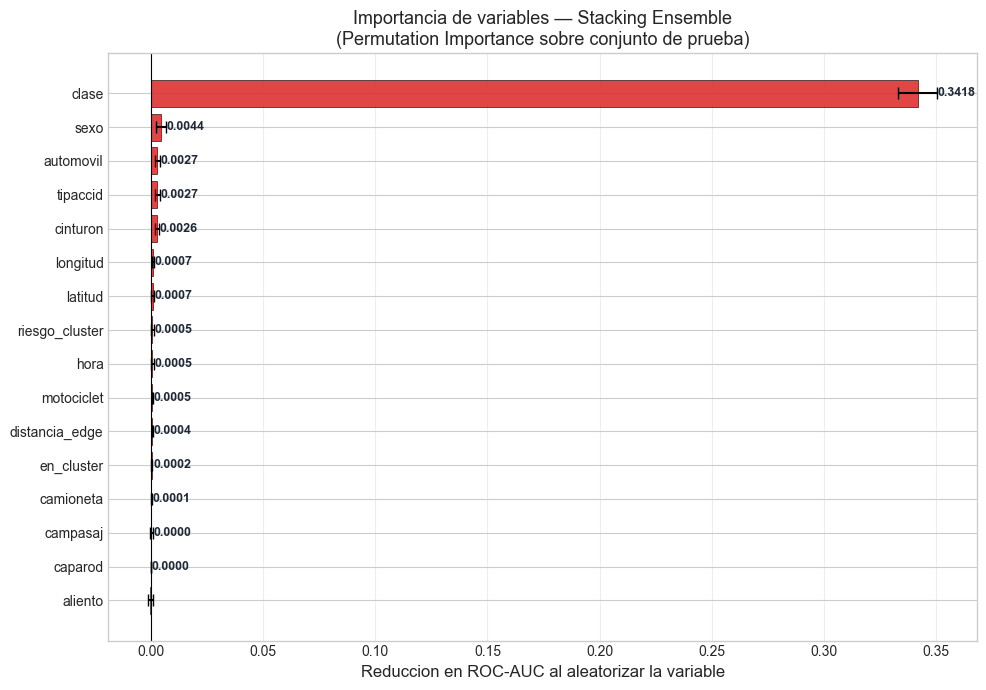

Top 5 variables mas importantes:
              media       std
clase      0.341815  0.008820
sexo       0.004368  0.002221
automovil  0.002665  0.001175
tipaccid   0.002662  0.001168
cinturon   0.002556  0.001030


In [76]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    stack, X_test_sc, y_test,
    n_repeats=15, random_state=42, n_jobs=-1, scoring='roc_auc'
)

importancias = pd.DataFrame({
    'media': perm.importances_mean,
    'std':   perm.importances_std,
}, index=FEATURES).sort_values('media', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colores = ['#dc2626' if v > 0 else '#9ca3af' for v in importancias['media']]
bars = ax.barh(importancias.index, importancias['media'],
               xerr=importancias['std'], color=colores,
               edgecolor='black', linewidth=0.5, capsize=4, alpha=0.85)
for bar, val, std in zip(bars, importancias['media'], importancias['std']):
    xpos = val + std + 0.0003
    if val >= 0:
        ax.text(xpos, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9, fontweight='bold', color='#1f2937')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Reduccion en ROC-AUC al aleatorizar la variable', fontsize=12)
ax.set_title('Importancia de variables — Stacking Ensemble\n'
             '(Permutation Importance sobre conjunto de prueba)', fontsize=13)
ax.grid(axis='x', alpha=0.35)
plt.tight_layout()
plt.show()

print('Top 5 variables mas importantes:')
print(importancias.sort_values('media', ascending=False).head(5)[['media','std']].to_string())

* clase (0.34) — tipo de accidente (colisión, volcadura, atropellamiento…). Domina el modelo: el tipo de evento determina en gran medida si hay muertos/heridos graves

* sexo (0.004) — sexo del conductor (hombres tienen mayor riesgo de accidente grave)

* automovil (0.003) — si el vehículo es auto particular. 

* tipaccid (0.003) — subtipo de accidente (complementa a clase con más detalle)

* cinturon (0.003) — uso de cinturón. Impacta directamente en la gravedad de las lesiones

## 12. Guardar modelos


In [77]:
from pathlib import Path

# Guardar umbral optimo como atributo del modelo
stack.best_threshold_ = float(best_threshold)

# Eliminar modelo anterior si existe
old_model = Path('modelos/modelo_riesgo_rf.pkl')
if old_model.exists():
    old_model.unlink()
    print('Modelo anterior (modelo_riesgo_rf.pkl) eliminado.')

with open('modelos/modelo_riesgo_stack.pkl', 'wb') as f:
    pickle.dump(stack, f)

with open('modelos/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('modelos/feature_names.pkl', 'wb') as f:
    pickle.dump(FEATURES, f)

print('Modelos guardados:')
print('  modelos/modelo_riesgo_stack.pkl')
print('  modelos/scaler.pkl')
print('  modelos/feature_names.pkl')
print(f'Umbral optimo guardado en el modelo: {best_threshold:.3f}')

Modelo anterior (modelo_riesgo_rf.pkl) eliminado.
Modelos guardados:
  modelos/modelo_riesgo_stack.pkl
  modelos/scaler.pkl
  modelos/feature_names.pkl
Umbral optimo guardado en el modelo: 0.941


## 13. Scoring de riesgo compuesto

Para cada punto del dataset se calcula un indice de riesgo compuesto que combina:
- Riesgo historico: normalizado de la cantidad de accidentes historicos por tramo.
- Riesgo por clustering: derivado del tamano del cluster DBSCAN.
- Riesgo ML: probabilidad predicha por el modelo de que el accidente sea grave.

La ponderacion 0.6 / 0.1 / 0.3 refleja que los datos historicos son la fuente
mas confiable, el clustering captura la densidad local y el ML agrega capacidad
de prediccion condicionada a las caracteristicas del accidente.


In [78]:
extra_cols = [c for c in ['id', 'latitud', 'longitud'] if c not in FEATURES]
df_scoring = df_ml[FEATURES + extra_cols].dropna().copy()

X_sc = scaler.transform(df_scoring[list(scaler.feature_names_in_)])
df_scoring['riesgo_ml'] = stack.predict_proba(X_sc)[:, 1] * 100

if 'n_accidentes_tramo' in df_scoring.columns:
    mn = df_scoring['n_accidentes_tramo'].min()
    mx = df_scoring['n_accidentes_tramo'].max()
    df_scoring['riesgo_historico'] = (df_scoring['n_accidentes_tramo'] - mn) / max(mx - mn, 1) * 100
else:
    df_scoring['riesgo_historico'] = df_scoring['riesgo_ml']

if 'riesgo_cluster' not in df_scoring.columns:
    df_scoring['riesgo_cluster'] = 0

df_scoring['indice_riesgo_compuesto'] = (
    0.6 * df_scoring['riesgo_historico'] +
    0.1 * df_scoring['riesgo_cluster'] +
    0.3 * df_scoring['riesgo_ml']
).clip(0, 100)

df_scoring[['id', 'riesgo_cluster', 'riesgo_ml',
             'indice_riesgo_compuesto', 'latitud', 'longitud']].to_csv(
    'Datos combinados CDMX/SCORING_RIESGO_COMPUESTO.csv', index=False
)

print(f'Scoring generado para {len(df_scoring):,} puntos.')
print(f'Riesgo compuesto  media: {df_scoring["indice_riesgo_compuesto"].mean():.1f}')
print(f'                  max:   {df_scoring["indice_riesgo_compuesto"].max():.1f}')
print(f'                  min:   {df_scoring["indice_riesgo_compuesto"].min():.1f}')
print('Guardado: Datos combinados CDMX/SCORING_RIESGO_COMPUESTO.csv')

Scoring generado para 42,851 puntos.
Riesgo compuesto  media: 6.4
                  max:   100.0
                  min:   0.0
Guardado: Datos combinados CDMX/SCORING_RIESGO_COMPUESTO.csv


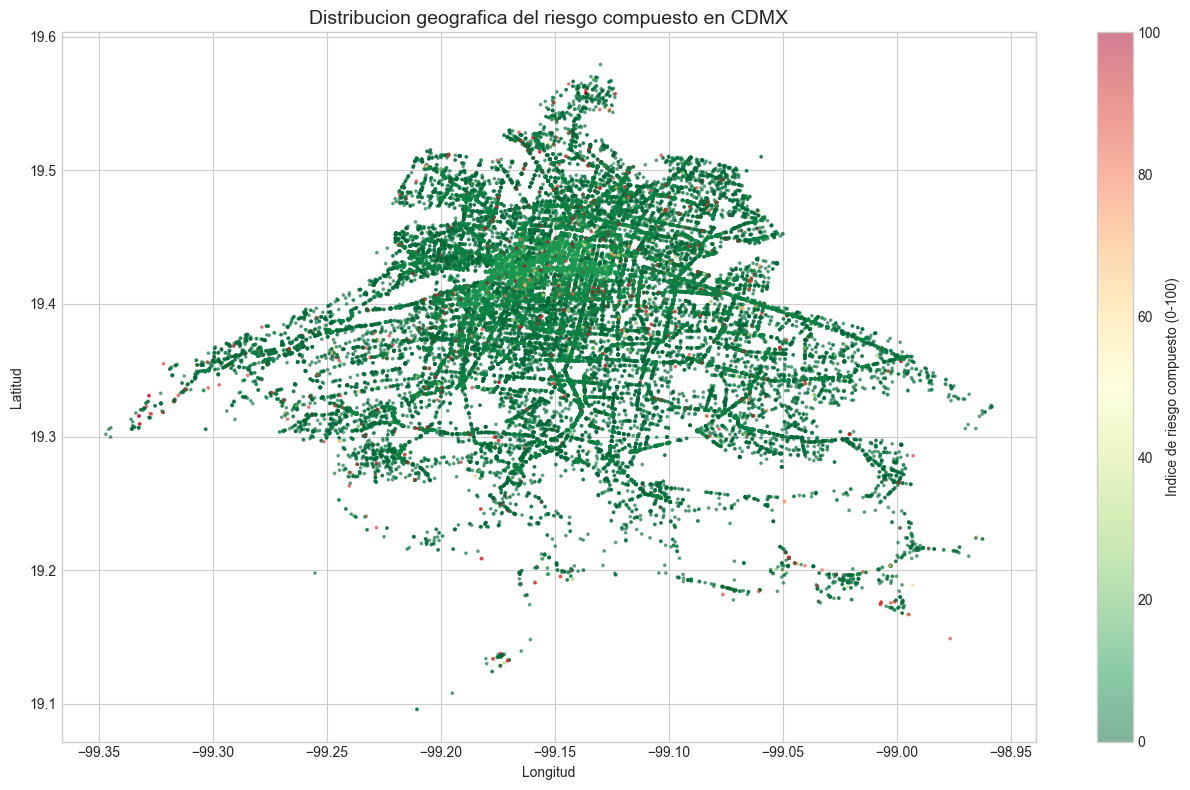

In [79]:
fig, ax = plt.subplots(figsize=(13, 8))
sc = ax.scatter(
    df_scoring['longitud'], df_scoring['latitud'],
    c=df_scoring['indice_riesgo_compuesto'],
    cmap='RdYlGn_r', s=3, alpha=0.5, vmin=0, vmax=100
)
plt.colorbar(sc, ax=ax, label='Indice de riesgo compuesto (0-100)')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_title('Distribucion geografica del riesgo compuesto en CDMX', fontsize=14)
plt.tight_layout()
plt.show()
